# Loading Data from a Static STAC Catalog

## Overview

[STAC (SpatioTemporal Asset Catalog)](https://stacspec.org/) is an open specification that makes geospatial data more discoverable and accessible. A *static* STAC catalog is a collection of JSON files hosted on a file server or object storage — no dedicated API server is required. This tutorial demonstrates how to search and load data from a static STAC catalog using [`pystac-client`](https://pystac-client.readthedocs.io/) and [`odc-stac`](https://odc-stac.readthedocs.io/). 

We use the [OpenLandMap STAC](https://stac.openlandmap.org/) catalog hosted on Wasabi cloud storage and load nighttime lights (VIIRS) imagery for Bangalore, India, comparing 2015 and 2020 to observe changes in urban extent and intensity.

**Input Layers**:

* `bangalore.geojson`: City boundary for Bangalore, India, used as the area of interest (AOI).

**Output**:

* `nightlights_2015.tif`: Cloud-Optimized GeoTIFF of nighttime lights radiance for 2015, clipped to Bangalore.
* `nightlights_2020.tif`: Cloud-Optimized GeoTIFF of nighttime lights radiance for 2020, clipped to Bangalore.

**Data Credit**:

*  Nighttime lights VIIRS dataset hosted on OpenLandMap STAC Catalog. Elvidge, C. D., Zhizhin, M., Ghosh, T., Hsu, F. C., & Taneja, J. (2021). Annual time series of global VIIRS nighttime lights derived from monthly averages: 2012 to 2019. Remote Sensing, 13(5), 922. https://doi.org/10.3390/rs13050922
* Bangalore Ward Maps Provided by Spatial Data of Municipalities (Maps) Project by Data{Meet}.

**Running the Notebook**:
The preferred way to run this notebook is on Google Colab.
<a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/stac_static_catalog.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Download
The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install pystac-client odc-stac rioxarray dask['distributed']

In [ ]:
from odc.stac import stac_load
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import pystac_client
import rioxarray as rxr
import xarray as xr


Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [ ]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

data_url = 'https://github.com/spatialthoughts/geopython-tutorials/releases/download/data/'
aoi = 'bangalore.geojson'
download(data_url + aoi)

## Search and Load Nighttime Lights Imagery

We load the GeoJSON boundary for the city of Bengaluru and extract its geometry.

In [ ]:
aoi_path = os.path.join(data_folder, aoi)
aoi_gdf = gpd.read_file(aoi_path)
geometry = aoi_gdf.geometry.union_all()

We can now load the OpenLandMap STAC Catalog and fetch the `nightlights.average_viirs.v21` collection. See [Read a STAC Catalog Using PySTAC](https://stacspec.org/en/tutorials/1-read-stac-python/) for more details on all available methods to browse a static catalog.

In [ ]:
catalog = pystac_client.Client.open(
    'https://s3.eu-central-1.wasabisys.com/stac/openlandmap/catalog.json')
ntl_collection = catalog.get_child('nightlights.average_viirs.v21')

Fetch all STAC Items.

In [ ]:
items = list(ntl_collection.get_all_items())
items[0]

/usr/local/lib/python3.12/dist-packages/pystac_client/collection_client.py:149: FallbackToPystac: Falling back to pystac. This might be slow.
  root._warn_about_fallback("ITEM_SEARCH")


<Item id=nightlights.average_viirs.v21_20000101_20001231>


> Note: Currently there is an error in the bounding box metadata for items in this collection. The order of coordinates is swapped `(62.000833333333446, -180.0, 87.37, 180.00000000000028)` which should be `(-180.0, 62.000833333333446, -180.0, 180.00000000000028, 87.37)`. This results in empty results when loading data for certain regions.

##

## Load Images

In [ ]:
ds = stac_load(
    items,
    bands=['nightlights.average_viirs.v21_m_500m_s'],
    resolution=500,
    bbox=geometry.bounds,
    crs='utm',
    chunks={},  # <-- use Dask
)
ds

<xarray.Dataset> Size: 445kB
Dimensions:                                 (y: 70, x: 72, time: 22)
Coordinates:
  * y                                       (y) float64 560B 1.455e+06 ... 1....
  * x                                       (x) float64 576B 7.668e+05 ... 8....
  * time                                    (time) datetime64[ns] 176B 2000-0...
    spatial_ref                             int32 4B 32643
Data variables:
    nightlights.average_viirs.v21_m_500m_s  (time, y, x) float32 444kB dask.array<chunksize=(1, 70, 72), meta=np.ndarray>

In [ ]:
da = ds['nightlights.average_viirs.v21_m_500m_s']

In [ ]:
da_subset = da.sel(time=['2015', '2020'])
da_subset

In [ ]:
%%time
da_subset = da_subset.compute()

In [ ]:
geometry_crs = aoi_gdf.to_crs(da_subset.rio.crs).geometry
da_clipped = da_subset.rio.clip(geometry_crs)

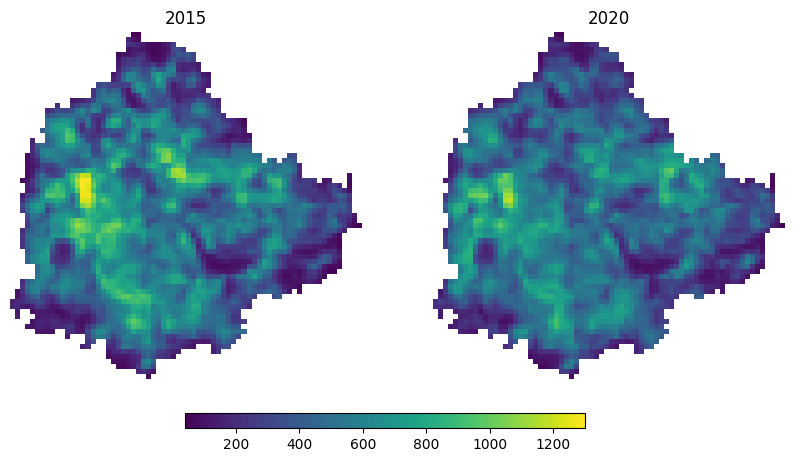

In [ ]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(10, 5)

# Determine the global min and max for consistent scaling
vmin = da_clipped.min().item()
vmax = da_clipped.max().item()

plot_image_0 = da_clipped.sel(time='2015').plot(
    ax=axes[0], vmin=vmin, vmax=vmax, add_colorbar=False)
axes[0].set_title('2015')

plot_image_1 = da_clipped.sel(time='2020').plot(
    ax=axes[1], vmin=vmin, vmax=vmax, add_colorbar=False)
axes[1].set_title('2020')

for ax in axes.flat:
  ax.set_axis_off()
  ax.set_aspect('equal')

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.03]) # [left, bottom, width, height]
fig.colorbar(plot_image_0, cax=cbar_ax, orientation='horizontal')

plt.show()

## Save Images

In [ ]:
def export_year(year):
    da_year = da_clipped.sel(time=f'{year}', method='nearest')
    file_name = f'nightlights_{year}.tif'
    file_path = os.path.join(output_folder, file_name)
    da_year.rio.to_raster(file_path, driver='COG')
    print(f'Saved nightlights for {year} to {file_path}')

export_year('2015')
export_year('2020')